In [2]:
# Importations des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Modèles de régression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor

# Configuration
pd.set_option('display.max_columns', None)
np.random.seed(42)

# Configuration du style des graphiques
try:
    sns.set_style("whitegrid")
    print("Style seaborn appliqué avec succès")
except Exception as e:
    print(f"Erreur dans l'application du style: {str(e)}")
    plt.style.use('ggplot')
    print("Style ggplot appliqué comme solution de repli")

Style seaborn appliqué avec succès


In [3]:
# Chargement des données
try:
    df = pd.read_csv("C:\\Users\\zizou\\OneDrive\\Desktop\\stage 3ème\\day 2\\csvfiles\\dataframefinale.csv", sep=';')
    print(f"Dimensions des données: {df.shape}")
    print("\nAperçu des données:")
    display(df.head())
except Exception as e:
    print(f"Erreur lors du chargement des données: {str(e)}")
    raise

Dimensions des données: (19995, 13)

Aperçu des données:


,dataloadingdate,Jour,Mois,NumeroSemaine,Trimestre,JourSemaineNum,JourSemaine,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
0,01/07/2025,1,7,27,3,1,Tuesday,TN0008000739,"BTA 7,4% Fevrier 2030",1459.0,1.500,62.0,7.6
1,01/07/2025,1,7,27,3,1,Tuesday,TN0008000739,"BTA 7,4% Fevrier 2030",291.0,0.300,183.0,7.5
2,01/07/2025,1,7,27,3,1,Tuesday,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,50000.0,5.000,13.0,8.6
3,01/07/2025,1,7,27,3,1,Tuesday,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,10000.0,1.000,7.0,8.6
4,01/07/2025,1,7,27,3,1,Tuesday,TN0008000606,"BTA 6,7% Avril 2028",5660.0,5.742,31.0,9.1


In [4]:
# Conversion des colonnes numériques
numeric_cols = ['Nombre de Titres', 'Montant', 'Echéance', 'Taux', 'Jour', 'Mois', 'NumeroSemaine', 'Trimestre', 'JourSemaineNum']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '.'), errors='coerce')

# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne:")
missing_data = df.isnull().sum()
display(missing_data[missing_data > 0])

# Suppression des valeurs manquantes
df = df.dropna()
print(f"\nDimensions après suppression des valeurs manquantes: {df.shape}")

# Vérification des doublons
duplicates = df.duplicated().sum()
print(f"\nNombre de doublons trouvés: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Dimensions après suppression des doublons: {df.shape}")


Valeurs manquantes par colonne:


Series([], dtype: int64)


Dimensions après suppression des valeurs manquantes: (19995, 13)

Nombre de doublons trouvés: 374
Dimensions après suppression des doublons: (19621, 13)


In [7]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, scaling=False, feature_selection=False):
    """
    Évalue un modèle et retourne les métriques RMSE pour train et test
    """
    # Entraînement du modèle
    model.fit(X_train, y_train)
    
    # Prédictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calcul des métriques
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2 = r2_score(y_test, y_test_pred)
    
    # Affichage des résultats
    print(f"\n{'='*50}")
    print(f"Évaluation du modèle: {model_name}")
    if scaling:
        print("Avec normalisation des données")
    if feature_selection:
        print("Avec sélection de features")
    print(f"- RMSE (train): {train_rmse:.4f}")
    print(f"- RMSE (test): {test_rmse:.4f}")
    print(f"- R² (test): {r2:.4f}")
    
    # Feature importance si disponible
    if hasattr(model, 'feature_importances_'):
        if hasattr(model, 'named_steps'):  # Pour les pipelines
            importances = model.named_steps['model'].feature_importances_
        else:
            importances = model.feature_importances_
            
        top_features = pd.Series(importances, index=X_train.columns if not feature_selection else selected_features)
        print("\nTop 5 des features les plus importantes:")
        display(top_features.sort_values(ascending=False).head(5))
    
    return {
        'model_name': model_name,
        'model': model,
        'scaling': scaling,
        'feature_selection': feature_selection,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'r2': r2
    }

In [8]:
# Liste des modèles à évaluer
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regression': SVR(),
    'K-Neighbors Regressor': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

# Évaluation des modèles de base
print("=== ÉVALUATION DES MODÈLES DE BASE ===")
base_results = []
for name, model in models.items():
    result = evaluate_model(model, X_train, X_test, y_train, y_test, name)
    base_results.append(result)

=== ÉVALUATION DES MODÈLES DE BASE ===

Évaluation du modèle: Linear Regression
- RMSE (train): 6.8444
- RMSE (test): 6.7405
- R² (test): 0.2819

Évaluation du modèle: Ridge Regression
- RMSE (train): 6.8444
- RMSE (test): 6.7405
- R² (test): 0.2819

Évaluation du modèle: Random Forest
- RMSE (train): 1.3540
- RMSE (test): 3.5135
- R² (test): 0.8049

Top 5 des features les plus importantes:


Nombre de Titres    0.643802
Taux                0.162192
Echéance            0.076755
NumeroSemaine       0.047768
Jour                0.027648
dtype: float64


Évaluation du modèle: Gradient Boosting
- RMSE (train): 4.1012
- RMSE (test): 4.3496
- R² (test): 0.7010

Top 5 des features les plus importantes:


Nombre de Titres    0.717803
Taux                0.166477
Echéance            0.063052
NumeroSemaine       0.026758
Mois                0.007943
dtype: float64


Évaluation du modèle: Support Vector Regression
- RMSE (train): 6.9891
- RMSE (test): 6.7656
- R² (test): 0.2765

Évaluation du modèle: K-Neighbors Regressor
- RMSE (train): 4.6084
- RMSE (test): 5.8155
- R² (test): 0.4654

Évaluation du modèle: Decision Tree
- RMSE (train): 0.0157
- RMSE (test): 5.1458
- R² (test): 0.5815

Top 5 des features les plus importantes:


Nombre de Titres    0.641691
Taux                0.181143
Echéance            0.085709
NumeroSemaine       0.050942
Jour                0.017694
dtype: float64

In [9]:
# Évaluation avec normalisation
print("\n=== ÉVALUATION AVEC NORMALISATION ===")
scaled_results = []
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    result = evaluate_model(pipeline, X_train, X_test, y_train, y_test, name, scaling=True)
    scaled_results.append(result)


=== ÉVALUATION AVEC NORMALISATION ===

Évaluation du modèle: Linear Regression
Avec normalisation des données
- RMSE (train): 6.8444
- RMSE (test): 6.7405
- R² (test): 0.2819

Évaluation du modèle: Ridge Regression
Avec normalisation des données
- RMSE (train): 6.8444
- RMSE (test): 6.7405
- R² (test): 0.2818

Évaluation du modèle: Random Forest
Avec normalisation des données
- RMSE (train): 1.3568
- RMSE (test): 3.5133
- R² (test): 0.8049

Évaluation du modèle: Gradient Boosting
Avec normalisation des données
- RMSE (train): 4.1012
- RMSE (test): 4.3495
- R² (test): 0.7010

Évaluation du modèle: Support Vector Regression
Avec normalisation des données
- RMSE (train): 6.3193
- RMSE (test): 6.1026
- R² (test): 0.4113

Évaluation du modèle: K-Neighbors Regressor
Avec normalisation des données
- RMSE (train): 4.8523
- RMSE (test): 5.9477
- R² (test): 0.4409

Évaluation du modèle: Decision Tree
Avec normalisation des données
- RMSE (train): 0.0157
- RMSE (test): 5.1390
- R² (test): 0.5826

In [10]:
# Sélection des k meilleures features
k = 10  # Nombre de features à sélectionner
selector = SelectKBest(score_func=f_regression, k=k)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]
print(f"\nFeatures sélectionnées (SelectKBest): {list(selected_features)}")

# Évaluation avec feature selection
print("\n=== ÉVALUATION AVEC SÉLECTION DE FEATURES ===")
feature_selection_results = []
for name, model in models.items():
    result = evaluate_model(model, X_train_selected, X_test_selected, y_train, y_test, 
                          name, feature_selection=True)
    feature_selection_results.append(result)

c:\Users\zizou\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:776: UserWarning: k=10 is greater than n_features=8. All the features will be returned.
  warnings.warn(



Features sélectionnées (SelectKBest): ['Jour', 'Mois', 'NumeroSemaine', 'Trimestre', 'JourSemaineNum', 'Nombre de Titres', 'Echéance', 'Taux']

=== ÉVALUATION AVEC SÉLECTION DE FEATURES ===

Évaluation du modèle: Linear Regression
Avec sélection de features
- RMSE (train): 6.8444
- RMSE (test): 6.7405
- R² (test): 0.2819

Évaluation du modèle: Ridge Regression
Avec sélection de features
- RMSE (train): 6.8444
- RMSE (test): 6.7405
- R² (test): 0.2819

Évaluation du modèle: Random Forest
Avec sélection de features
- RMSE (train): 1.3540
- RMSE (test): 3.5135
- R² (test): 0.8049

Top 5 des features les plus importantes:


Nombre de Titres    0.643802
Taux                0.162192
Echéance            0.076755
NumeroSemaine       0.047768
Jour                0.027648
dtype: float64


Évaluation du modèle: Gradient Boosting
Avec sélection de features
- RMSE (train): 4.1012
- RMSE (test): 4.3496
- R² (test): 0.7010

Top 5 des features les plus importantes:


Nombre de Titres    0.717803
Taux                0.166477
Echéance            0.063052
NumeroSemaine       0.026758
Mois                0.007943
dtype: float64


Évaluation du modèle: Support Vector Regression
Avec sélection de features
- RMSE (train): 6.9891
- RMSE (test): 6.7656
- R² (test): 0.2765

Évaluation du modèle: K-Neighbors Regressor
Avec sélection de features
- RMSE (train): 4.6084
- RMSE (test): 5.8155
- R² (test): 0.4654

Évaluation du modèle: Decision Tree
Avec sélection de features
- RMSE (train): 0.0157
- RMSE (test): 5.1458
- R² (test): 0.5815

Top 5 des features les plus importantes:


Nombre de Titres    0.641691
Taux                0.181143
Echéance            0.085709
NumeroSemaine       0.050942
Jour                0.017694
dtype: float64

In [12]:
# Optimisation des Hyperparamètres - Version corrigée

# Définition des grilles de paramètres avec le préfixe 'model__'
param_grids = {
    'Random Forest': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10]
    },
    'Gradient Boosting': {
        'model__n_estimators': [50, 100, 200],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5, 7]
    },
    'Ridge Regression': {
        'model__alpha': [0.1, 1.0, 10.0, 100.0]
    },
    'Support Vector Regression': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf'],
        'model__gamma': ['scale', 'auto']
    },
    'K-Neighbors Regressor': {
        'model__n_neighbors': [3, 5, 7, 9],
        'model__weights': ['uniform', 'distance']
    }
}

# Sélection des 5 meilleurs modèles de base
all_results = base_results + scaled_results + feature_selection_results
top_models_info = sorted(all_results, key=lambda x: x['test_rmse'])[:5]
top_models_names = [res['model_name'] for res in top_models_info]

print("\n=== OPTIMISATION DES 5 MEILLEURS MODÈLES ===")
print(f"Modèles sélectionnés pour optimisation: {top_models_names}")

optimized_results = []
for model_info in top_models_info:
    name = model_info['model_name']
    if name in param_grids:
        print(f"\nOptimisation du modèle: {name}")
        
        # Création du pipeline si nécessaire
        if model_info['scaling']:
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('model', model_info['model'].named_steps['model'] if hasattr(model_info['model'], 'named_steps') 
                          else model_info['model'])
            ])
        else:
            pipeline = Pipeline([('model', model_info['model'])])
        
        # Configuration de GridSearchCV
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            cv=5,
            scoring='neg_root_mean_squared_error',
            n_jobs=-1,
            verbose=1
        )
        
        # Données à utiliser
        if model_info['feature_selection']:
            grid_search.fit(X_train_selected, y_train)
            X_test_to_use = X_test_selected
        else:
            grid_search.fit(X_train, y_train)
            X_test_to_use = X_test
        
        # Récupération du meilleur modèle
        optimized_model = grid_search.best_estimator_
        
        # Évaluation du modèle optimisé
        result = evaluate_model(
            optimized_model,
            X_train_selected if model_info['feature_selection'] else X_train,
            X_test_to_use,
            y_train,
            y_test,
            f"Optimized {name}",
            scaling=model_info['scaling'],
            feature_selection=model_info['feature_selection']
        )
        
        optimized_results.append(result)
        print(f"Meilleurs paramètres pour {name}: {grid_search.best_params_}")


=== OPTIMISATION DES 5 MEILLEURS MODÈLES ===
Modèles sélectionnés pour optimisation: ['Random Forest', 'Random Forest', 'Random Forest', 'Gradient Boosting', 'Gradient Boosting']

Optimisation du modèle: Random Forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Évaluation du modèle: Optimized Random Forest
Avec normalisation des données
- RMSE (train): 1.3504
- RMSE (test): 3.5117
- R² (test): 0.8051
Meilleurs paramètres pour Random Forest: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Optimisation du modèle: Random Forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Évaluation du modèle: Optimized Random Forest
- RMSE (train): 1.3484
- RMSE (test): 3.5118
- R² (test): 0.8051
Meilleurs paramètres pour Random Forest: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Optimisation du modèle: Random Forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Évaluation 


=== RÉSULTATS COMPARATIFS ===


,model_name,scaling,feature_selection,train_rmse,test_rmse,r2
24,Optimized Gradient Boosting,True,False,0.938244,3.438378,0.813132
25,Optimized Gradient Boosting,False,False,0.938244,3.442342,0.812701
21,Optimized Random Forest,True,False,1.350375,3.511710,0.805076
23,Optimized Random Forest,False,True,1.348427,3.511783,0.805068
22,Optimized Random Forest,False,False,1.348427,3.511783,0.805068
9,Random Forest,True,False,1.356752,3.513252,0.804905
2,Random Forest,False,False,1.353994,3.513464,0.804881
16,Random Forest,False,True,1.353994,3.513464,0.804881
10,Gradient Boosting,True,False,4.101167,4.349479,0.700978
3,Gradient Boosting,False,False,4.101167,4.349584,0.700964


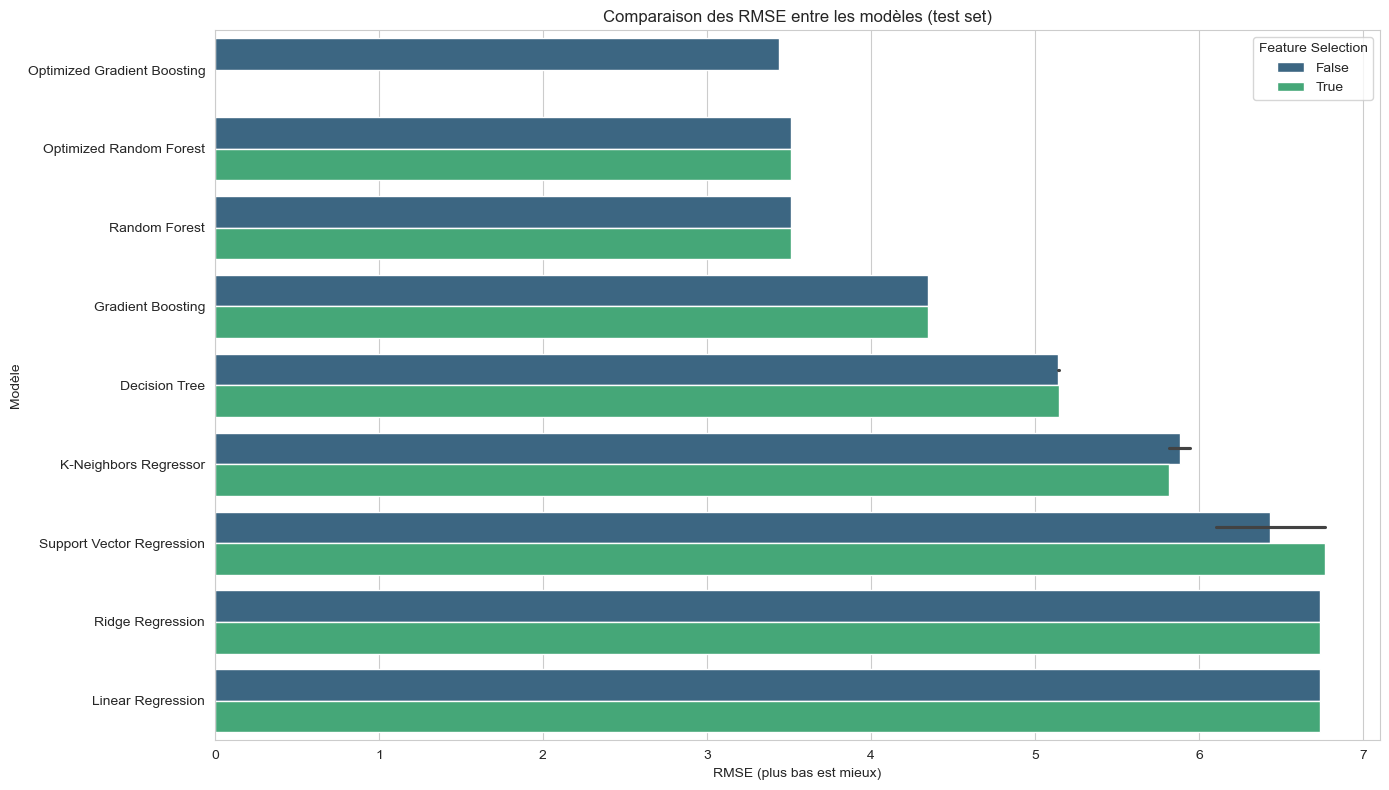

In [13]:
# Combinaison de tous les résultats
all_results = base_results + scaled_results + feature_selection_results + optimized_results
results_df = pd.DataFrame(all_results)

# Tri par RMSE sur le test set
results_df = results_df.sort_values(by='test_rmse')

# Affichage des résultats
print("\n=== RÉSULTATS COMPARATIFS ===")
display(results_df[['model_name', 'scaling', 'feature_selection', 'train_rmse', 'test_rmse', 'r2']])

# Visualisation
plt.figure(figsize=(14, 8))
sns.barplot(
    data=results_df,
    x='test_rmse',
    y='model_name',
    hue='feature_selection',
    palette='viridis'
)
plt.title('Comparaison des RMSE entre les modèles (test set)')
plt.xlabel('RMSE (plus bas est mieux)')
plt.ylabel('Modèle')
plt.legend(title='Feature Selection')
plt.tight_layout()
plt.show()

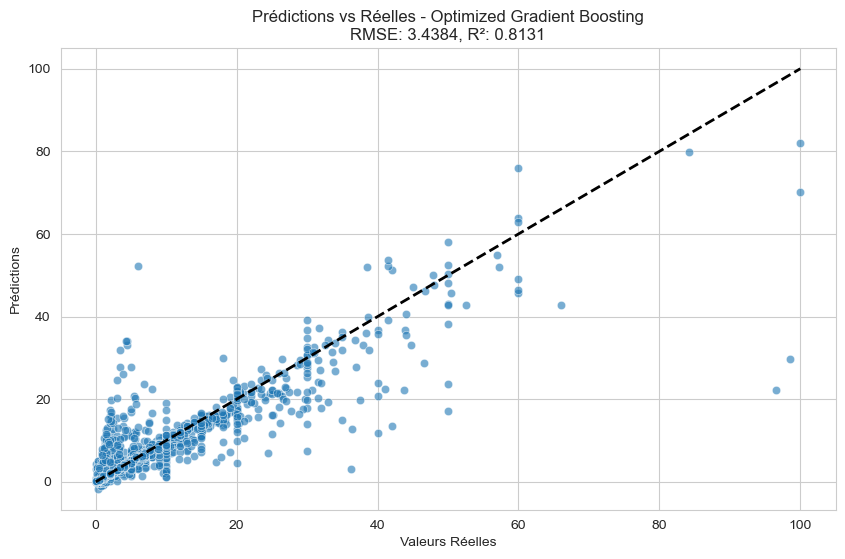

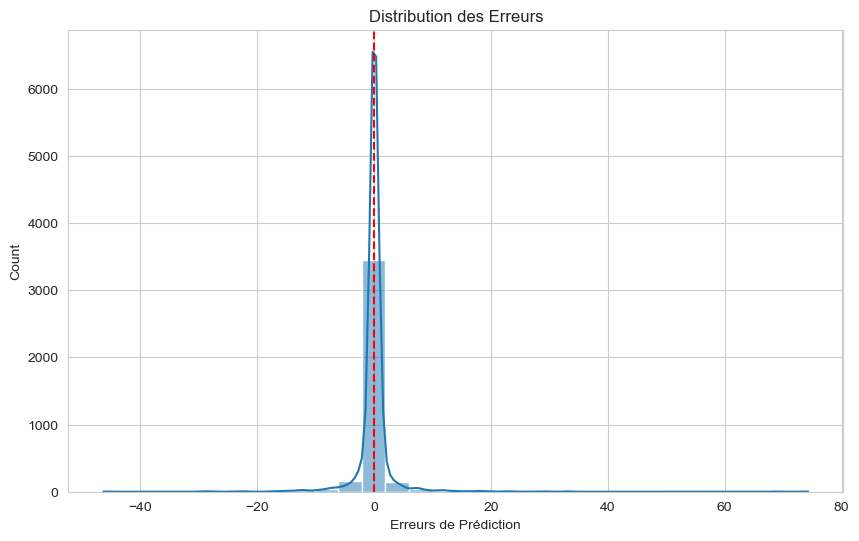

In [14]:
# Sélection du meilleur modèle
best_result = results_df.iloc[0]
best_model = best_result['model']

# Préparation des données pour la visualisation
if best_result['feature_selection']:
    y_pred = best_model.predict(X_test_selected)
    features_used = selected_features
else:
    y_pred = best_model.predict(X_test)
    features_used = X.columns

# Graphique des prédictions vs valeurs réelles
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Valeurs Réelles')
plt.ylabel('Prédictions')
plt.title(f'Prédictions vs Réelles - {best_result["model_name"]}\nRMSE: {best_result["test_rmse"]:.4f}, R²: {best_result["r2"]:.4f}')
plt.show()

# Distribution des erreurs
errors = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True, bins=30)
plt.xlabel('Erreurs de Prédiction')
plt.title('Distribution des Erreurs')
plt.axvline(x=0, color='r', linestyle='--')
plt.show()

# Feature Importance si disponible
if hasattr(best_model, 'feature_importances_'):
    if hasattr(best_model, 'named_steps'):  # Pour les pipelines
        importances = best_model.named_steps['model'].feature_importances_
    else:
        importances = best_model.feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': features_used,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
    plt.title('Top 10 des Features les plus Importantes')
    plt.tight_layout()
    plt.show()

In [15]:
import joblib
import datetime

# Création d'un répertoire pour les résultats
import os
os.makedirs('model_results', exist_ok=True)

# Sauvegarde des résultats
results_path = os.path.join('model_results', f'results_{datetime.datetime.now().strftime("%Y%m%d_%H%M")}.csv')
results_df.to_csv(results_path, index=False)
print(f"Résultats sauvegardés dans: {results_path}")

# Sauvegarde du meilleur modèle
model_path = os.path.join('model_results', 'best_model.pkl')
joblib.dump(best_model, model_path)
print(f"Meilleur modèle sauvegardé dans: {model_path}")

# Sauvegarde des features utilisées
features_path = os.path.join('model_results', 'selected_features.pkl')
joblib.dump(list(features_used), features_path)
print(f"Features utilisées sauvegardées dans: {features_path}")

# Sauvegarde des paramètres du meilleur modèle
if hasattr(best_model, 'get_params'):
    params = best_model.get_params()
    params_path = os.path.join('model_results', 'best_model_params.json')
    pd.Series(params).to_json(params_path)
    print(f"Paramètres du modèle sauvegardés dans: {params_path}")

Résultats sauvegardés dans: model_results\results_20250731_1236.csv
Meilleur modèle sauvegardé dans: model_results\best_model.pkl
Features utilisées sauvegardées dans: model_results\selected_features.pkl
Paramètres du modèle sauvegardés dans: model_results\best_model_params.json


In [16]:
print("=== SYNTHÈSE FINALE ===")
print(f"\nMeilleur modèle: {best_result['model_name']}")
print(f"- RMSE (test): {best_result['test_rmse']:.4f}")
print(f"- R² (test): {best_result['r2']:.4f}")
print(f"- Avec normalisation: {'Oui' if best_result['scaling'] else 'Non'}")
print(f"- Avec sélection de features: {'Oui' if best_result['feature_selection'] else 'Non'}")

print("\nAnalyse des performances:")
print("1. Écart entre train et test RMSE:")
print(f"   - Différence: {best_result['train_rmse'] - best_result['test_rmse']:.4f}")
print("   - Interprétation: Une petite différence indique un bon équilibre biais-variance")

print("\n2. Qualité de la prédiction (R²):")
print(f"   - R² de {best_result['r2']:.4f} indique que le modèle explique "
      f"{best_result['r2']*100:.2f}% de la variance des données")

print("\nRecommandations:")
print("- Pour améliorer davantage, envisager:")
print("  * Feature engineering supplémentaire")
print("  * Essayer d'autres techniques de sélection de features")
print("  * Augmenter la quantité de données d'entraînement")
print("  * Essayer des techniques d'ensemble plus avancées")

=== SYNTHÈSE FINALE ===

Meilleur modèle: Optimized Gradient Boosting
- RMSE (test): 3.4384
- R² (test): 0.8131
- Avec normalisation: Oui
- Avec sélection de features: Non

Analyse des performances:
1. Écart entre train et test RMSE:
   - Différence: -2.5001
   - Interprétation: Une petite différence indique un bon équilibre biais-variance

2. Qualité de la prédiction (R²):
   - R² de 0.8131 indique que le modèle explique 81.31% de la variance des données

Recommandations:
- Pour améliorer davantage, envisager:
  * Feature engineering supplémentaire
  * Essayer d'autres techniques de sélection de features
  * Augmenter la quantité de données d'entraînement
  * Essayer des techniques d'ensemble plus avancées
